# Insurance Regression

## Import necessary libraries

In [76]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.dummy import DummyRegressor
from scipy.stats import uniform, randint

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")

### Data Loading & Initial Inspection

In [77]:
path = r"C:\Users\ADMIN\Desktop\Logic Mojo_AIML Jan26\Resources\March\Week 3\16\insurance.csv"

In [78]:
# Load the dataset
df = pd.read_csv(path)

# Look at the first 5 rows
df.head()

# Check data types and look for missing (null) values
print("\n--- Data Info ---")
df.info()

print("=== Summary Statistics ======")
df.describe(include="all")


--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
=== Summary Statistics ======


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [79]:
# Check for duplicate rows and missing values
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'\nValue counts - smoker\n{df["smoker"].value_counts().rename("smoker").rename_axis(None)}')
print(f'\nValue Count - region\n{df["region"].value_counts().rename("region").rename_axis(None)}')

Duplicate rows: 1
Missing values : 0

Value counts - smoker
no     1064
yes     274
Name: smoker, dtype: int64

Value Count - region
southeast    364
southwest    325
northwest    325
northeast    324
Name: region, dtype: int64


### Exploratory Data Analysis (EDA)

In [80]:
# Define the columns as lists to make it easier to work with them later
Num_Cols = ['age','bmi','children']
Cat_Cols = ['sex','smoker','region']
target = 'charges'

print(f'\nNumerical Columns {Num_Cols}')
print(f'\nCategorical Columns {Cat_Cols}')
print(f'\nTarget Columns - {target}')


Numerical Columns ['age', 'bmi', 'children']

Categorical Columns ['sex', 'smoker', 'region']

Target Columns - charges


### Univariate Analysis

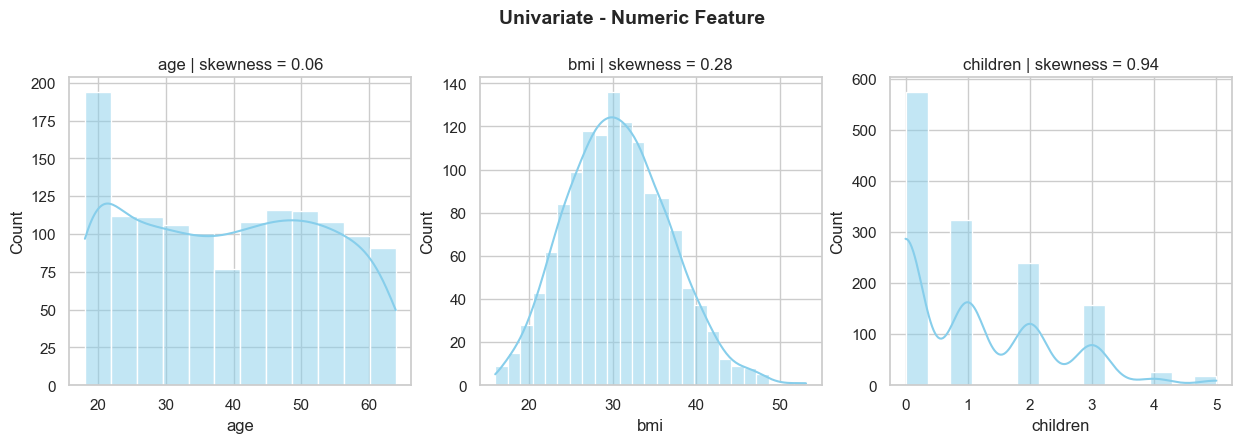

Skewness summary:
age         :0.056
bmi         :0.284
children    :0.938


In [81]:
# Numerical Features (Histograms)
plt.figure(figsize=(15,4))

for i, col in enumerate(Num_Cols):
    plt.subplot(1,3,i+1)
    sns.histplot(data=df, x=col, kde=True , color='skyblue')
    skew = df[col].skew()
    plt.title(f'{col} | skewness = {skew:.2f}')

plt.suptitle('Univariate - Numeric Feature' , fontsize=14, fontweight='bold' , y=1.05)
plt.show()

print('Skewness summary:')
for col in Num_Cols:
    print(f'{col:<12}:{df[col].skew():.3f}')



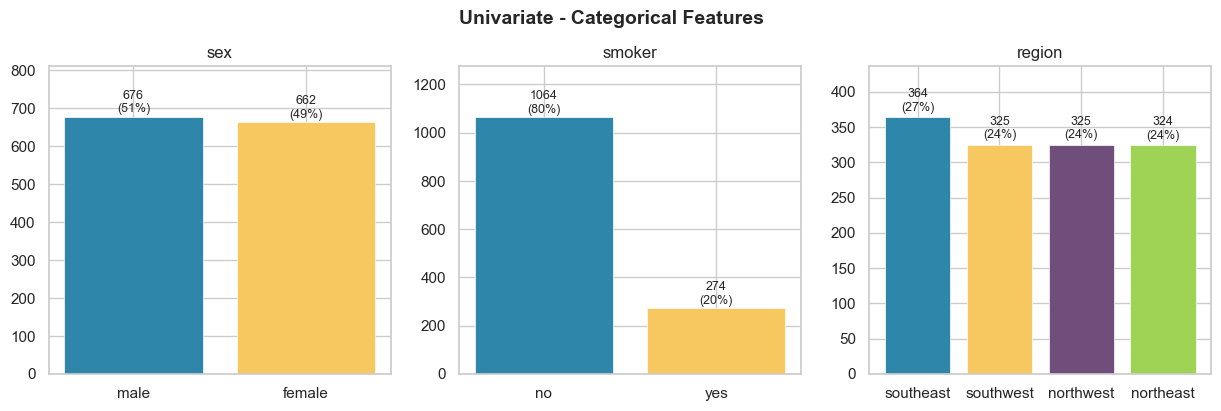

In [8]:
# Categorical column
plt.figure(figsize=(15,4))

for i, col in enumerate(Cat_Cols):
    plt.subplot(1 ,3, i+1)
    vc = df[col].value_counts()
    colors = ['#2E86AB', '#F6C85F', '#6F4E7C', '#9FD356'][:len(vc)]
    bars = plt.bar(vc.index, vc.values, color=colors, edgecolor='white', linewidth=0.5)
    for bar , v in zip(bars,vc.values):
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f'{v}\n({v/len(df)*100:.0f}%)',
                 ha="center",
                 va="bottom",
                 fontsize=9)

    plt.ylim(0, max(vc.values) * 1.2)
    plt.title(col)

plt.suptitle('Univariate - Categorical Features' , fontsize=14, fontweight='bold', y=1.02)
plt.show()

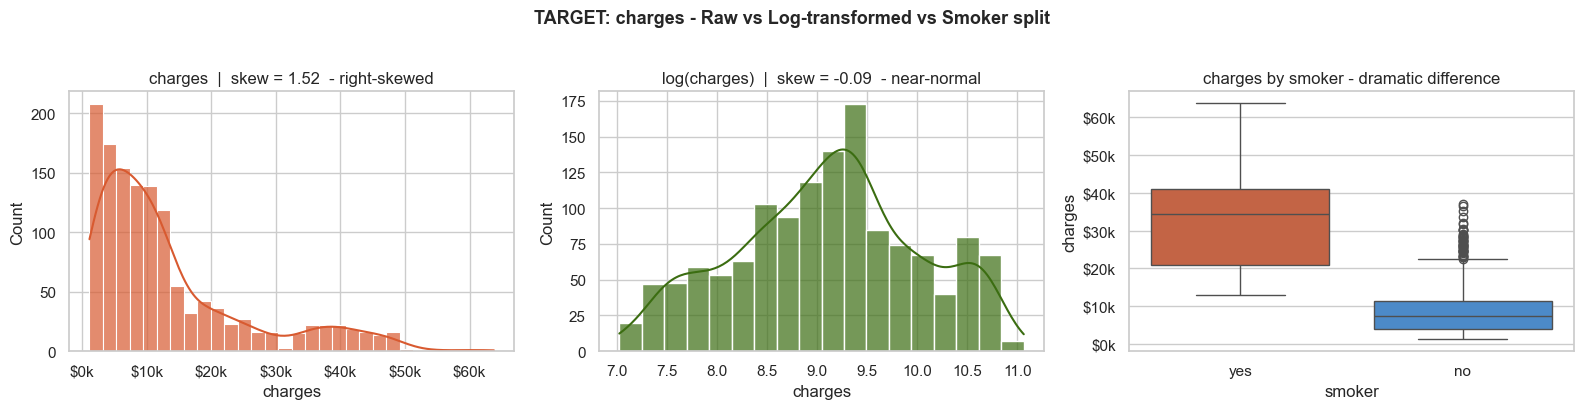

All charges - mean: $13,270  |  median: $9,382
Smokers     - mean: $32,050
Non-smokers - mean: $8,434


In [82]:
import matplotlib.ticker as mticker

# Print the actual metric for skewness. (closer to 0 is symmetric, > 0.5 is skewed)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
PALETTE = {'no': '#378ADD', 'yes': '#D85A30'}

# Raw charges
sns.histplot(df['charges'], kde=True, ax=axes[0], color='#D85A30', alpha=0.7, edgecolor='white')
axes[0].set_title(f'charges  |  skew = {df["charges"].skew():.2f}  - right-skewed')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))

# Log-transformed
log_charges = np.log1p(df['charges'])
sns.histplot(log_charges, kde=True, ax=axes[1], color='#3B6D11', alpha=0.7, edgecolor='white')
axes[1].set_title(f'log(charges)  |  skew = {log_charges.skew():.2f}  - near-normal')

# Boxplot by smoker
sns.boxplot(data=df, x='smoker', y='charges', palette=PALETTE, ax=axes[2])
axes[2].set_title('charges by smoker - dramatic difference')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))

plt.suptitle('TARGET: charges - Raw vs Log-transformed vs Smoker split',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'All charges - mean: ${df["charges"].mean():,.0f}  |  median: ${df["charges"].median():,.0f}')
print(f'Smokers     - mean: ${df[df["smoker"]=="yes"]["charges"].mean():,.0f}')
print(f'Non-smokers - mean: ${df[df["smoker"]=="no"]["charges"].mean():,.0f}')

### Bivariate Anlaysis

<Axes: xlabel='age', ylabel='charges'>

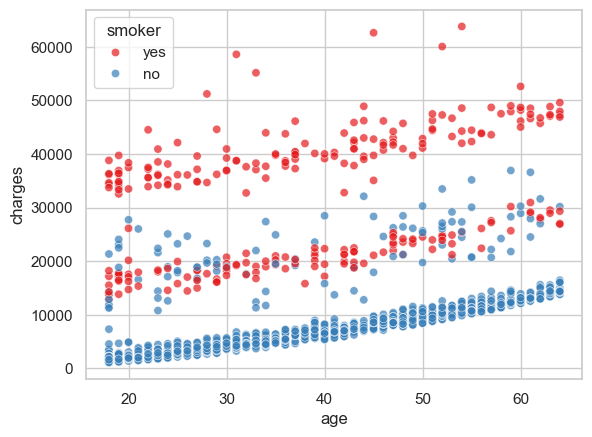

In [83]:
sns.scatterplot(
    data=df,
    x='age',
    y='charges',
    palette='Set1',
    hue='smoker',
    alpha=0.7
)

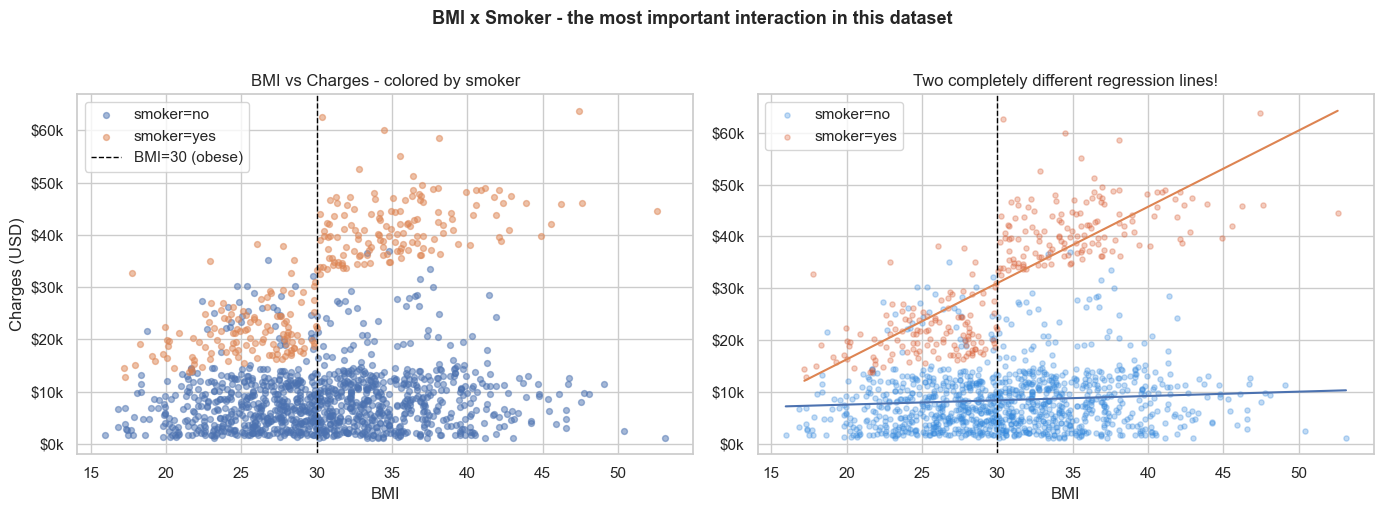

In [84]:
# Create 1 row x 2 columns of subplots to compare raw scatter vs fitted lines
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: scatter of BMI vs Charges, colored by smoking status
for smoke_val, grp in df.groupby('smoker'):
    axes[0].scatter(grp['bmi'], grp['charges'],
                    alpha=0.5, s=18, label=f'smoker={smoke_val}')
# Vertical line at BMI=30 (clinical obesity threshold)
axes[0].axvline(30, color='black', linestyle='--', linewidth=1, label='BMI=30 (obese)')
axes[0].set_title('BMI vs Charges - colored by smoker')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Charges (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
axes[0].legend()

# Right plot: same scatter + separate linear regression line per smoker group
for smoke_val, grp in df.groupby('smoker'):
    axes[1].scatter(grp['bmi'], grp['charges'], c=PALETTE[smoke_val],
                    alpha=0.3, s=14, label=f'smoker={smoke_val}')
    # Fit slope (m) and intercept (b) for this group; plot the line
    m, b = np.polyfit(grp['bmi'], grp['charges'], 1)
    x_line = np.linspace(grp['bmi'].min(), grp['bmi'].max(), 100)
    axes[1].plot(x_line, m*x_line+b)
axes[1].axvline(30, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Two completely different regression lines!')
axes[1].set_xlabel('BMI')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
axes[1].legend()

plt.suptitle('BMI x Smoker - the most important interaction in this dataset',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Data PreProcessing

In [85]:
df_model = df.copy()

# Binary encoding
df_model['smoker_enc'] = (df_model['smoker'] == 'yes').astype(int)
df_model['sex_enc']    = (df_model['sex'] == 'male').astype(int)

# One-hot encoding for region (drop_first avoids dummy variable trap)
df_model = pd.get_dummies(df_model, columns=['region'], drop_first=True, dtype=int)

# Log-transform target
df_model['log_charges'] = np.log1p(df_model['charges'])

# Drop original text columns
df_model.drop(['smoker', 'sex', 'charges', 'obese'], axis=1, inplace=True, errors='ignore')

print('Encoded dataframe shape:', df_model.shape)
print('\nColumns:', list(df_model.columns))
df_model.head(3)

Encoded dataframe shape: (1338, 9)

Columns: ['age', 'bmi', 'children', 'smoker_enc', 'sex_enc', 'region_northwest', 'region_southeast', 'region_southwest', 'log_charges']


,age,bmi,children,smoker_enc,sex_enc,region_northwest,region_southeast,region_southwest,log_charges
0,19,27.90,0,1,0,0,0,1,9.734236
1,18,33.77,1,0,1,0,1,0,7.453882
2,28,33.00,3,0,1,0,1,0,8.400763


In [86]:
feature_col = [c for c in df_model.columns if c != 'log_charges']
X = df_model[feature_col]
y = df_model['log_charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'X_Train :{X_train.shape}')
print(f'X_Test : {X_test.shape}')

X_Train :(1070, 8)
X_Test : (268, 8)


In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_column = ['age', 'bmi', 'children'] # only numerical column needs scaling

X_train_scaled = X_train.copy() # creating copies of original data
X_test_scaled  = X_test.copy()
X_train_scaled[num_column] = scaler.fit_transform(X_train[num_column])
X_test_scaled[num_column]  = scaler.transform(X_test[num_column])

In [88]:
X_train_scaled

,age,bmi,children,smoker_enc,sex_enc,region_northwest,region_southeast,region_southwest
560,0.472227,-1.756525,0.734336,0,0,1,0,0
1285,0.543313,-1.033082,-0.911192,0,0,0,0,0
1142,0.898745,-0.943687,-0.911192,0,0,0,1,0
969,-0.025379,0.622393,3.202629,0,0,0,1,0
486,1.040918,-1.504893,1.557100,0,0,1,0,0
...,...,...,...,...,...,...,...,...
1095,-1.518194,0.130717,2.379865,0,0,0,0,0
1130,-0.025379,-1.107579,3.202629,0,0,0,1,0
1294,1.325264,-0.891539,-0.911192,0,1,0,0,0
860,-0.167551,2.820864,0.734336,1,0,0,0,1


## R2-Score with Custom Feature and without Custom Feature

### Custom Feature creation

In [107]:
def add_engineered_features(X_df):
    X = X_df.copy()
    X['bmi_smoker']  = X['bmi'] * X['smoker_enc']
    X['obese']       = (X['bmi'] >= 30).astype(int)
    X['obese_smoker']= X['obese'] * X['smoker_enc']
    X['age_sq']      = X['age'] ** 2
    X['age_smoker']  = X['age'] * X['smoker_enc']
    return X

X_train_eng = add_engineered_features(X_train)
X_test_eng  = add_engineered_features(X_test)

SCALE_COLS_ENG = ['age', 'bmi', 'children', 'bmi_smoker', 'age_sq', 'age_smoker']
scaler_eng = StandardScaler()
X_train_eng_s = X_train_eng.copy()
X_test_eng_s  = X_test_eng.copy()
X_train_eng_s[SCALE_COLS_ENG] = scaler_eng.fit_transform(X_train_eng[SCALE_COLS_ENG])
X_test_eng_s[SCALE_COLS_ENG]  = scaler_eng.transform(X_test_eng[SCALE_COLS_ENG])

print(f'Base features    : {X_train.shape[1]}')
print(f'Engineered feats : {X_train_eng.shape[1]}')
print(f'New features     : {list(set(X_train_eng.columns)-set(X_train.columns))}')


Base features    : 8
Engineered feats : 13
New features     : ['age_smoker', 'obese', 'obese_smoker', 'age_sq', 'bmi_smoker']


In [117]:
X_test_eng_s

,age,bmi,children,smoker_enc,sex_enc,region_northwest,region_southeast,region_southwest,bmi_smoker,obese,obese_smoker,age_sq,age_smoker
764,0.401140,-0.891539,0.734336,0,0,0,0,0,-0.495987,0,0,0.247042,-0.470101
887,-0.238638,-0.089461,-0.911192,0,0,1,0,0,-0.495987,1,0,-0.400463,-0.470101
890,1.751782,-0.608453,-0.911192,1,0,1,0,0,1.629044,0,0,2.086526,3.388985
1293,0.472227,-0.797177,1.557100,0,1,1,0,0,-0.495987,0,0,0.327869,-0.470101
259,-1.447107,0.225079,-0.911192,1,1,1,0,0,2.027018,1,1,-1.230940,0.675565
...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,1.680696,0.749865,-0.911192,1,1,0,1,0,2.277580,1,1,1.973723,3.328687
575,1.325264,-0.561272,-0.911192,0,0,1,0,0,-0.495987,0,0,1.436356,-0.470101
535,-0.096465,-0.419729,-0.088428,0,1,0,0,0,-0.495987,0,0,-0.269008,-0.470101
543,1.040918,2.789410,-0.911192,1,0,0,1,0,3.251371,1,1,1.038438,2.786003


### Without Custom Feature

In [113]:
scaler = StandardScaler()
num_column = ['age', 'bmi', 'children'] # only numerical column needs scaling

X_train_scaled = X_train.copy() # creating copies of original data
X_test_scaled  = X_test.copy()
X_train_scaled[num_column] = scaler.fit_transform(X_train[num_column])
X_test_scaled[num_column]  = scaler.transform(X_test[num_column])

In [114]:
X_test_scaled

,age,bmi,children,smoker_enc,sex_enc,region_northwest,region_southeast,region_southwest
764,0.401140,-0.891539,0.734336,0,0,0,0,0
887,-0.238638,-0.089461,-0.911192,0,0,1,0,0
890,1.751782,-0.608453,-0.911192,1,0,1,0,0
1293,0.472227,-0.797177,1.557100,0,1,1,0,0
259,-1.447107,0.225079,-0.911192,1,1,1,0,0
...,...,...,...,...,...,...,...,...
109,1.680696,0.749865,-0.911192,1,1,0,1,0
575,1.325264,-0.561272,-0.911192,0,0,1,0,0
535,-0.096465,-0.419729,-0.088428,0,1,0,0,0
543,1.040918,2.789410,-0.911192,1,0,0,1,0


In [116]:
# with custom feature
custom_r2 = LinearRegression()
custom_r2.fit(X_train_eng_s,y_train)
custom_predict_log = custom_r2.predict(X_test_eng_s)
custom_r2 = r2_score(y_test,custom_predict_log)
custom_r2

# Without custom feature
base_r2 = LinearRegression()
base_r2.fit(X_train_scaled,y_train)
pred_log = base_r2.predict(X_test_scaled)
r2 = r2_score(y_test,pred_log)
r2


print(f'R2 Score without custom feature - {r2}')
print(f'R2 Score with custom feature - {custom_r2}')

R2 Score without custom feature - 0.804741079139302
R2 Score with custom feature - 0.8566201861966597


In [125]:
summary_data = [
    ['Without Feature Engineering', f'{r2*100:.2f}%'],
    ['With Feature Engineering',    f'{custom_r2*100:.2f}%'],
    ['Improvement',                 f'+{(custom_r2*100) - (r2*100):.2f}%']
]

df_summary = pd.DataFrame(summary_data, columns=['Approach', '  R2 Score'])
print(df_summary.to_string(index=False))

                   Approach   R2 Score
Without Feature Engineering     80.47%
   With Feature Engineering     85.66%
                Improvement     +5.19%
